In [1]:
import argparse

def str_to_bool(value):
    """Convert argument string to boolean."""
    if isinstance(value, bool):
        return value
    if value.lower() in ('true', '1', 'yes', 'y'):
        return True
    elif value.lower() in ('false', '0', 'no', 'n'):
        return False
    else:
        raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
def int_or_str(val):
    try:
        return int(val)
    except ValueError:
        return val

parser = argparse.ArgumentParser()
parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
parser.add_argument("--subset_size", type=float, required=True)
parser.add_argument("--noadv", type=str_to_bool, required=True)

parser.add_argument("--max_epochs", type=int, required=True)

parser.add_argument("--KL_scaling", type=float, required=True)
parser.add_argument("--n_cat_discriminator_train", type=int, required=True)
parser.add_argument("--n_pert_discriminator_train", type = int, required = True)
parser.add_argument("--gen_max_lr", type=float, required=True)
parser.add_argument("--pert_spectral_norm", type=str_to_bool, required=True)
parser.add_argument("--cat_spectral_norm", type=str_to_bool, required=True)

parser.add_argument("--cat_max_penalty_weight", type=int, required=True)

########################################################################
args = parser.parse_args()
fn = str(args.index)

subset_size = args.subset_size
no_adv = args.noadv
KL_scaling = args.KL_scaling
max_epochs = args.max_epochs
n_cat_discriminator_train = args.n_cat_discriminator_train
n_pert_discriminator_train = args.n_pert_discriminator_train
gen_max_lr = args.gen_max_lr
pert_spectral_norm = args.pert_spectral_norm
cat_spectral_norm = args.cat_spectral_norm
cat_max_penalty_weight = args.cat_max_penalty_weight


# python test_run.py --index 24 --subset_size 0.05 --noadv false --max_epochs 600 --KL_scaling 1e-2 --n_cat_discriminator_train 5 --n_pert_discriminator_train 5 --gen_max_lr 1e-2 --pert_spectral_norm true --cat_spectral_norm true --cat_max_penalty_weight 11


In [101]:
# fn = '24'
# subset_size = 0.05
# no_adv = False
# KL_scaling = 1e-2
# max_epochs = 600
# n_cat_discriminator_train = 5
# n_pert_discriminator_train = 5
# gen_max_lr = 1e-2
# pert_spectral_norm = True
# cat_spectral_norm = True
# cat_max_penalty_weight = 11

In [102]:
import os
import time
import math

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

import Tahoe_utils as Tu

In [103]:
subset = True

In [104]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"



Load data:

In [105]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

# Train/test split:

In [106]:
train_split, test_split = Tu.Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = True, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [107]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [108]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


In [109]:
if subset:
    train_cells = []
    np.random.seed(seed)
    for cond in train_split['conditions'].condition:
        subset_cond = tf_adata.obs[tf_adata.obs.condition == cond]
        subset_cells = list(np.random.choice(
            subset_cond.index,
            size = int(np.round(subset_cond.shape[0] * subset_size)),
            replace = False
        ))
        train_cells+=subset_cells
    tf_adata = tf_adata[tf_adata.obs_names.isin(train_cells + test_cells),:].copy()
    adata = adata[tf_adata.obs_names, :].copy()
    expr = adata.to_df().copy()

**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [110]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts=4,
                       n_cat_discriminator_train=5,
                       n_pert_discriminator_train=5,
                       n_adversarial_start=0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    For 'generator', it updates when either discriminator is active.

    Returns:
        Dict of scheduler parameters
    """

    total_active_epochs = n_epochs
    n_steps = n_epochs  # default for SCL

    if role in ['cat_discriminator', 'pert_discriminator']:
        total_active_epochs = n_epochs - n_adversarial_start
        n_steps = total_active_epochs // 1

    elif role == 'generator':
        # Generator steps on any epoch divisible by either cat or pert discriminator schedule
        effective_epochs = range(n_adversarial_start, n_epochs)
        n_steps = sum(
            (e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0)
            for e in effective_epochs
        )

    T_0 = max(1, n_steps // n_restarts)
    warmup_epochs = max(1, n_steps // 10)

    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,
        'n_optimizer_resets': 0,
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }


In [111]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}

In [112]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')
per_condition_loss = False # TODO: check this


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}


max_batch_scaler = 24

if subset:
    if subset_size < 0.02:
        batch_scaler = 2
    else:
        batch_scaler = int(8 * round(math.ceil(subset_size / 0.05) * 0.05, 2) / 0.05)
        batch_scaler = min(batch_scaler, max_batch_scaler)
    batch_size = int(512*batch_scaler)

# max_epochs = 600


max_lr = 0.001
lr_scaling_factor = 10
lr_decay = 0.75
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
                               n_cat_discriminator_train = np.nan, 
                               n_pert_discriminator_train = np.nan,
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [113]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': 1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': 1e-6,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': 0, # using cat max norm
    'cat_bias_lambda_L1': 0, # using cat max norm
    'cat_bias_orthogonality_scaler': 0
}

In [114]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [115]:
# building
n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': KL_scaling, #1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

n_adversarial_start = 0 
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = gen_max_lr, #max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                               n_cat_discriminator_train = n_cat_discriminator_train, 
                               n_pert_discriminator_train = n_pert_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [116]:
discriminator_lambda_L2 = 1e-3

discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': np.nan, #False,
    'dropout_rate': np.nan,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': discriminator_lambda_L2,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

In [117]:
# architecture -- pert >> cat bc harder classification problem
cat_n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    cat_n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes
cat_discriminator_params['dropout_rate'] = 0.3
cat_discriminator_params['spectral_norm'] = cat_spectral_norm
if cat_spectral_norm:
    cat_discriminator_params['discriminator_lambda_L2'] = 0


pert_n_layers_disc = 4
pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     pert_n_layers_disc + 2)).astype(int)[1:-1])

# add 3 additional "starting" layers since classifying perturbation is difficult
pert_disc_n_hidden_nodes = [pert_disc_n_hidden_nodes[0]]*3 + pert_disc_n_hidden_nodes

pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes
pert_discriminator_params['dropout_rate'] = 0.1
pert_discriminator_params['spectral_norm'] = pert_spectral_norm
if pert_spectral_norm:
    pert_discriminator_params['discriminator_lambda_L2'] = 0

cat_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.cell_line.nunique()
pert_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.drug.nunique()

In [124]:
def expand_elements(lst, n_discriminator_train):
    return [x for x in lst for _ in range(n_discriminator_train)]


# adverserial penalty curve
cat_max_penalty_weight = 11
cat_b_adv = 2.5
pert_max_penalty_weight = 10 #15
pert_b_adv = 2 #10

n_adj = 1 if n_cat_discriminator_train > 1 else 0
cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = int((max_epochs - n_adversarial_start)/n_cat_discriminator_train) - n_adj,
    min_penalty_weight = 0.1,
    max_penalty_weight = cat_max_penalty_weight,
    a = 1,
    b = cat_b_adv, 
    curve_type = 'power')
cat_discriminator_penalty_weight = expand_elements(cat_discriminator_penalty_weight, n_cat_discriminator_train)
cat_discriminator_penalty_weight = [0]*n_adj*n_cat_discriminator_train + cat_discriminator_penalty_weight
cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

n_pert_train = 300
pert_discriminator_penalty_weight = [0] * n_pert_train

n_adj = n_pert_discriminator_train if n_pert_discriminator_train > 1 and n_pert_train == 0 else 0
pdpw2 = pp.discriminator_weight_curve(
    n_epochs = int((max_epochs - n_pert_train - n_adversarial_start)/n_pert_discriminator_train) - n_adj,
    min_penalty_weight = 1e-5,
    max_penalty_weight = pert_max_penalty_weight,
    a = 1,
    b = pert_b_adv, 
    curve_type = 'power')
pdpw2 = expand_elements(pdpw2, n_pert_discriminator_train)
pert_discriminator_penalty_weight += [0]*n_adj*n_pert_discriminator_train + pdpw2


pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

In [120]:
# discriminator LRs

# categorical
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
    n_pert_discriminator_train = np.nan,
    n_cat_discriminator_train = n_cat_discriminator_train,
    role = 'cat_discriminator')
del discriminator_lr_params['max_epochs']

cat_discriminator_params = {**cat_discriminator_params, **discriminator_lr_params}

# perturbation
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
    n_pert_discriminator_train = n_pert_discriminator_train,
    n_cat_discriminator_train = np.nan,
    role = 'pert_discriminator')
del discriminator_lr_params['max_epochs']

pert_discriminator_params = {**pert_discriminator_params, **discriminator_lr_params}

Visualize hyperparameters:

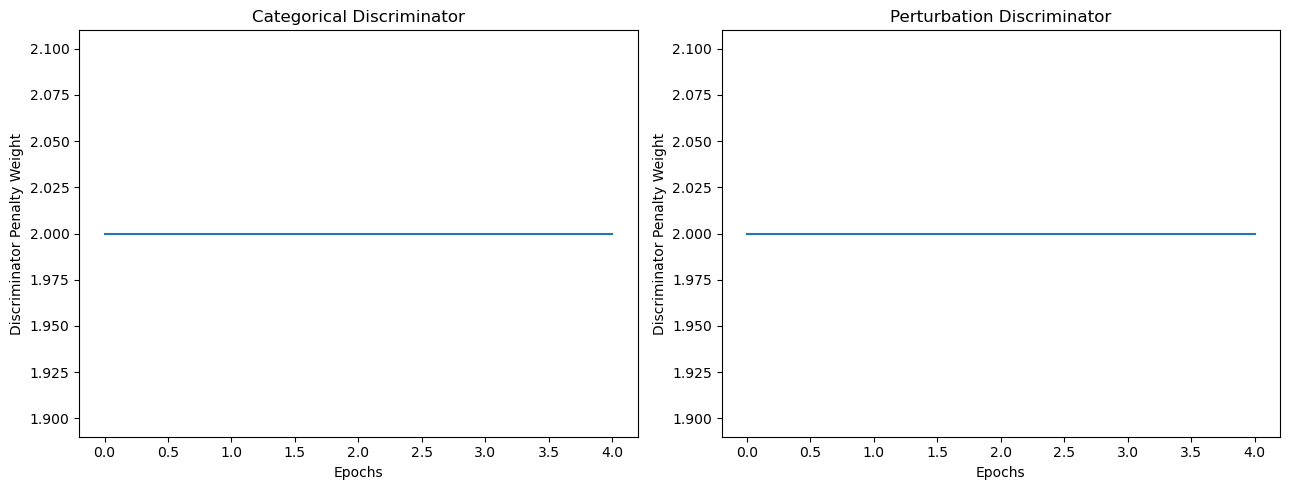

In [121]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [ ]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

100%|██████████████████████████████████████| 600/600 [00:00<00:00, 70078.32it/s]


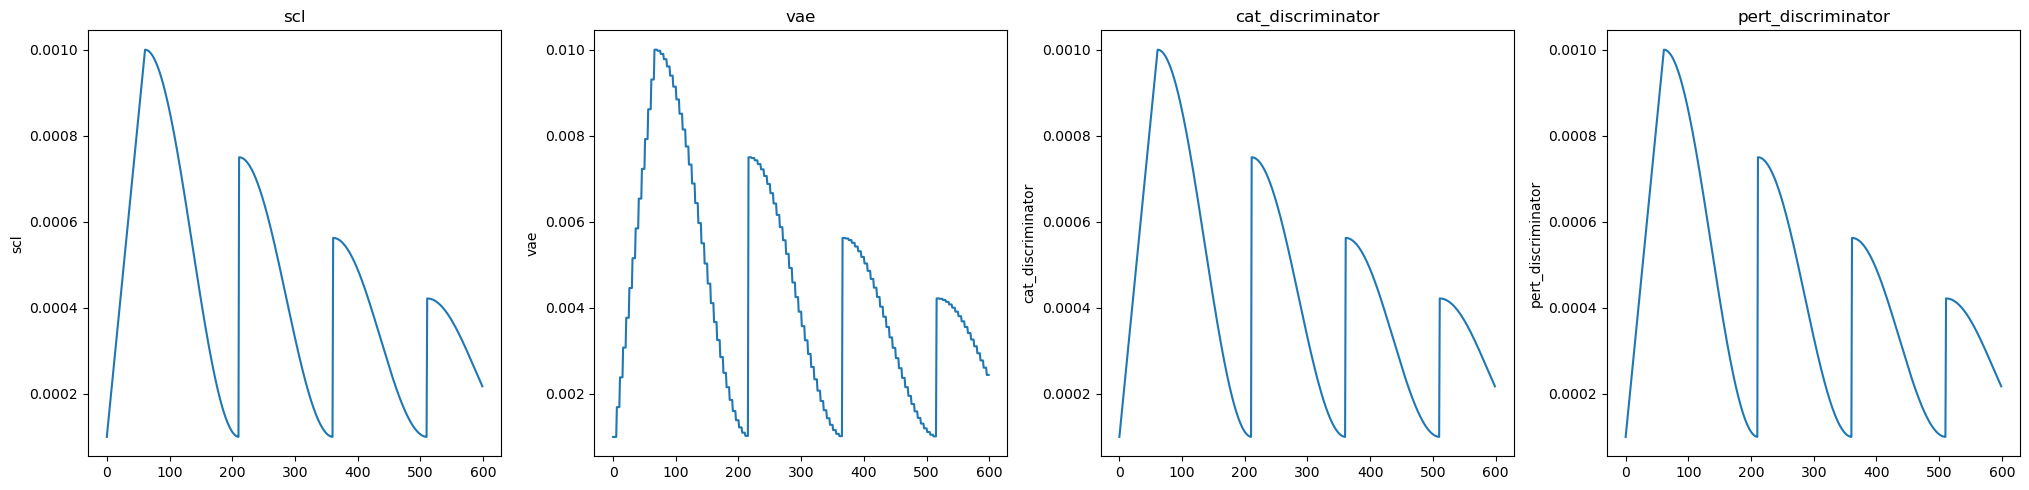

In [98]:
# lr_mod = SignalingModel(
#     net = sn_ppis,
#     X_in = X_in,
#     y_out = tf_adata.to_df().copy(), 
#     expr = expr, 
#     covariates = tf_adata.obs.copy(),
#     categorical_covariate_keys = ['cell_line'],
#     projection_amplitude_in = projection_amplitude_in, 
#     projection_amplitude_out = projection_amplitude_out,
#     weight_label = weight_label, source_label = source_label, target_label = target_label,
#     bionet_params = bionet_params, 
#     dtype = torch.float32, device = device, seed = mod_seed)

# lr_mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
# lr_mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius



# lr_trainer = TrainSC(
#     mod = mod,
#     prediction_optimizer = torch.optim.Adam,
#     prediction_loss_fn = prediction_loss_fn, 
#     per_condition_loss = per_condition_loss,
#     n_adversarial_start = n_adversarial_start, 
#     n_cat_discriminator_train = n_cat_discriminator_train,
#     n_pert_discriminator_train = n_pert_discriminator_train,
#     gradient_ascent = True,
#     cat_discriminator_params = cat_discriminator_params,
#     pert_discriminator_params = pert_discriminator_params,
#     vae_params = vae_params,
#     hyper_params = training_params,
#     train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
#     train_seed = mod_seed, 
#     track_test = True,
#     track_validation = False, 
#     n_eval_cells = np.nan, 
#     n_eval_bootstrap = np.nan
# )

# import collections
# from tqdm import trange
# lrs = collections.defaultdict(list)
# for e in trange(lr_trainer.hyper_params['max_epochs']):
#     lr_trainer._no_cat_vae = (
#         (e < lr_trainer.n_adversarial_start) or
#         (e % lr_trainer.n_cat_discriminator_train != 0) or
#         (e == 0 and lr_trainer.n_cat_discriminator_train > 1)
#     )

#     lr_trainer._no_pert_vae = (
#         (e < lr_trainer.n_adversarial_start) or
#         (e % lr_trainer.n_pert_discriminator_train != 0) or
#         (e == 0 and lr_trainer.n_pert_discriminator_train > 1)
#     )
#     lr_trainer._no_vae = (lr_trainer._no_cat_vae and lr_trainer._no_pert_vae)
    
#     lrs['scl'].append(lr_trainer.prediction_optimizer.param_groups[0]['lr'])
#     lrs['vae'].append(lr_trainer.vae_learning['optimizer'].param_groups[0]['lr'])
#     lrs['cat_discriminator'].append(lr_trainer.cat_discriminator['optimizer'].param_groups[0]['lr'])
#     lrs['pert_discriminator'].append(lr_trainer.pert_discriminator['optimizer'].param_groups[0]['lr'])


#     lr_trainer.lr_scheduler.step()
#     if lr_trainer.n_adversarial_start <= e:
#         lr_trainer.cat_discriminator['lr_scheduler'].step()
#         lr_trainer.pert_discriminator['lr_scheduler'].step()
#     if not lr_trainer._no_vae:
#         lr_trainer.vae_learning['lr_scheduler'].step()
        
# lrs = pd.DataFrame(lrs)

# ncols = lrs.shape[1]
# fig, ax = plt.subplots(ncols = ncols, figsize = (5.1*ncols, 5))

# for (j, col) in enumerate(lrs.columns):
#     sns.lineplot(lrs[col], ax = ax[j])
#     ax[j].set_title(col)
    
# fig.tight_layout()
# ;
# del lr_trainer

In [ ]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [25]:
if not no_adv:
    trainer = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = per_condition_loss,
        n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cat_discriminator_params,
        pert_discriminator_params = pert_discriminator_params,
        vae_params = vae_params,
        hyper_params = training_params,
        train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
        train_seed = mod_seed, 
        track_test = True,
        track_validation = False, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    
    if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
        mod = trainer.train_model(verbose = True)
        io.write_pickled_object(trainer, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))

else:
    pdp_noadv = pert_discriminator_params.copy()
    cdp_noadv = cat_discriminator_params.copy()

    pdp_noadv['discriminator_penalty_weight'] = 0.0
    cdp_noadv['discriminator_penalty_weight'] = 0.0

    trainer_noadv = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = per_condition_loss,
        n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cdp_noadv,
        pert_discriminator_params = pdp_noadv,
        vae_params = vae_params,
        hyper_params = training_params,
        train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
        train_seed = mod_seed, 
        track_test = True,
        track_validation = False, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    
    if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
        mod_noadv = trainer_noadv.train_model(verbose = True)
        io.write_pickled_object(trainer_noadv, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))    

In [ ]:
import papermill as pm
from nbconvert import HTMLExporter
import nbformat
import os

input_notebook = 'test_visualize.ipynb' # in the current directory
output_notebook = os.path.join(data_path, 'trash', fn +  '_' + author + '.ipynb')
output_html = os.path.join(data_path, 'trash', fn + '_' + author + '.html')

pm.execute_notebook(
    input_path=input_notebook,
    output_path=output_notebook,
    parameters={"fn": fn}, 
    kernel_name='python3'
)

nb = nbformat.read(output_notebook, as_version=4)
html_exporter = HTMLExporter()
html_exporter.exclude_input = True  # <-- hides code cells
(body, _) = html_exporter.from_notebook_node(nb)

with open(output_html, "w", encoding="utf-8") as f:
    f.write(body)
    
os.remove(output_notebook)